In [1]:
"""
===================================================================
ISM & eSRRF Rayleigh Resolution Benchmark: 2D Diagonal Line Chirp
===================================================================

This example evaluates 2D resolution limits across the super-resolution methods:
1. Range: 300 nm down to 90 nm line pair separations.
2. 2D Diagonal Chirp Pattern (angled at 45°).
3. 3-Subplot Stack per Method:
   - Row 1: Reconstructed 2D Image.
   - Row 2: 1D Profile Comparison (Ground Truth vs Reconstruction).
   - Row 3: Profile Agreement / Difference (Residual ΔI = I_recon - I_GT).
"""

'\n===================================================================\nISM & eSRRF Rayleigh Resolution Benchmark: 2D Diagonal Line Chirp\n===================================================================\n\nThis example evaluates 2D resolution limits across the super-resolution methods:\n1. Range: 300 nm down to 90 nm line pair separations.\n2. 2D Diagonal Chirp Pattern (angled at 45°).\n3. 3-Subplot Stack per Method:\n   - Row 1: Reconstructed 2D Image.\n   - Row 2: 1D Profile Comparison (Ground Truth vs Reconstruction).\n   - Row 3: Profile Agreement / Difference (Residual ΔI = I_recon - I_GT).\n'

In [2]:
import sys
from pathlib import Path
import os
# `__file__` does not exist inside a notebook; fall back to the working directory
_HERE_FILE = Path(globals().get("__file__", os.path.join(os.getcwd(), "example.py")))
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.signal import fftconvolve, correlate

In [3]:
import tttrlib

In [4]:
# The array-detector PSF model is a simulation helper, not part of the library
sim_dir = _HERE_FILE.resolve().parent.parent / "simulation"
if str(sim_dir) not in sys.path:
    sys.path.insert(0, str(sim_dir))

In [5]:
from simulate import generate_ism_psf

In [6]:
def generate_2d_diagonal_chirp_phantom(size_px: int = 180, pixel_size_nm: float = 15.0, line_width_nm: float = 20.0):
    """
    Generate 2D diagonal line pairs angled at 45° with separations from 300 nm down to 90 nm.
    Separations: 300, 250, 210, 170, 140, 115, 95 nm.
    """
    img = np.zeros((size_px, size_px), dtype=np.float64)
    separations_nm = [300, 250, 210, 170, 140, 115, 95]

    x = np.arange(size_px, dtype=float) * pixel_size_nm
    y = np.arange(size_px, dtype=float) * pixel_size_nm
    xx, yy = np.meshgrid(x, y)

    # 45-degree diagonal coordinate: u = (x + y) / sqrt(2)
    u = (xx + yy) / np.sqrt(2.0)

    sigma_nm = line_width_nm / 2.35482

    pair_info = []
    current_u = 140.0
    for sep in separations_nm:
        p1 = current_u
        p2 = current_u + sep
        pair_info.append((p1, p2, sep))
        current_u += sep + 150.0

    max_u = np.sqrt(2.0) * size_px * pixel_size_nm

    for p1, p2, _ in pair_info:
        if p2 < max_u - 120.0:
            img += np.exp(-((u - p1) ** 2) / (2.0 * sigma_nm ** 2))
            img += np.exp(-((u - p2) ** 2) / (2.0 * sigma_nm ** 2))

    # Mask outer margins
    img[:12, :] = 0
    img[-12:, :] = 0
    img[:, :12] = 0
    img[:, -12:] = 0

    return img, pair_info

In [7]:
def compute_modulation_depths(img2d: np.ndarray, pair_info: list, pixel_size_nm: float):
    """Calculate Rayleigh modulation depth M(d) along diagonal profile."""
    h, w = img2d.shape
    diag = np.array([img2d[i, i] for i in range(min(h, w))])
    u_grid = np.arange(len(diag)) * np.sqrt(2.0) * pixel_size_nm

    mods = []
    seps = []
    for p1, p2, sep in pair_info:
        idx1 = np.argmin(np.abs(u_grid - p1))
        idx2 = np.argmin(np.abs(u_grid - p2))
        if idx1 > idx2:
            idx1, idx2 = idx2, idx1
        if idx2 - idx1 <= 1:
            continue

        i1 = diag[idx1]
        i2 = diag[idx2]
        i_dip = diag[idx1:idx2 + 1].min()

        mod = float((i1 + i2 - 2.0 * i_dip) / (i1 + i2 + 1e-12))
        mods.append(max(0.0, min(1.0, mod)))
        seps.append(sep)

    return np.array(seps), np.array(mods)

In [8]:
def run_line_pattern_demo():
    pixel_size_nm = 15.0
    print(f"1. Generating 2D Diagonal Line Chirp Phantom (300-90 nm, {pixel_size_nm} nm/pixel)...")
    ground_truth, pair_info = generate_2d_diagonal_chirp_phantom(size_px=180, pixel_size_nm=pixel_size_nm)

    print("2. Simulating Physical 5x5 SPAD Array Detector PSFs (0.5 AU pitch)...")
    psf_sim = generate_ism_psf(
        na=1.4,
        wavelength_exc=488.0,
        wavelength_det=520.0,
        n_det=5,            # 5x5 SPAD detector array (25 channels)
        pitch_au=0.5,       # 0.5 Airy units pitch
        nx=64, ny=64,
        pixel_size_nm=pixel_size_nm
    )
    channel_psfs = psf_sim['channel_psfs']  # (25, 64, 64)

    print("3. Rendering 25-Channel Detector Array Image Cube...")
    n_det, ny, nx = 25, ground_truth.shape[0], ground_truth.shape[1]
    detector_cube = np.zeros((n_det, ny, nx), dtype=np.float64)

    for k in range(n_det):
        detector_cube[k] = fftconvolve(ground_truth, channel_psfs[k], mode='same')

    # Add Poisson photon noise
    detector_cube = np.random.poisson(np.clip(detector_cube * 150.0, 0, None)).astype(np.float64)

    print("4. Reconstructing Super-Resolution Images (All Methods + eSRRF)...")
    # Standard CLSM Open-Pinhole Sum
    clsm_sum = detector_cube.sum(axis=0)

    # 1. Pure eSRRF Map on Confocal Sum
    clsm_smooth = gaussian_filter(clsm_sum, sigma=0.8)
    rgc_esrrf = tttrlib.CLSMSuperRes.rgc_map(clsm_smooth, magnification=4, fwhm=2.5, sensitivity=1.0, intensity_weighting=True)

    # 2. Pure ISM Shift Reassignment (APR-ISM)
    apr_ism = tttrlib.CLSMSuperRes.apr_reconstruction(detector_cube, usf=10)[0]

    # 3. Focus-ISM Out-of-Focus Background Rejection (plane 0 = in-focus signal)
    focus_ism = tttrlib.CLSMSuperRes.focus_reconstruction(detector_cube, parallelize=True)[0]

    # 4. Combined eSRRF + ISM (RGC Radial Convergence on APR-ISM image)
    apr_smooth = gaussian_filter(apr_ism, sigma=0.8)
    esrrf_ism_combined = tttrlib.CLSMSuperRes.rgc_map(apr_smooth, magnification=1, fwhm=2.5, sensitivity=1.0, intensity_weighting=True)

    # Ground truth reference target
    gt_target = gaussian_filter(ground_truth, sigma=0.8)

    # Extract 1D diagonal profiles along (0,0) to (ny-1, nx-1)
    def extract_diagonal_profile(arr):
        h, w = arr.shape
        diag = np.array([arr[i, i] for i in range(min(h, w))])
        return diag

    gt_diag = extract_diagonal_profile(gt_target)
    gt_diag = (gt_diag - gt_diag.min()) / (gt_diag.max() - gt_diag.min() + 1e-12)

    def get_aligned_diag_profile(arr):
        p = extract_diagonal_profile(arr)
        if p.size != gt_diag.size:
            x_old = np.linspace(0, 1, p.size)
            x_new = np.linspace(0, 1, gt_diag.size)
            p = np.interp(x_new, x_old, p)

        # Cross-correlation alignment
        xcorr = correlate(p - p.mean(), gt_diag - gt_diag.mean(), mode='full')
        lags = np.arange(-len(gt_diag) + 1, len(gt_diag))
        best_lag = lags[np.argmax(xcorr)]

        if best_lag > 0:
            p = np.pad(p[:-best_lag], (best_lag, 0))
        elif best_lag < 0:
            p = np.pad(p[-best_lag:], (0, -best_lag))

        p_min, p_max = p.min(), p.max()
        if p_max > p_min:
            p = (p - p_min) / (p_max - p_min)
        return p

    gt_p = get_aligned_diag_profile(gt_target)
    clsm_p = get_aligned_diag_profile(clsm_sum)
    esrrf_p = get_aligned_diag_profile(rgc_esrrf)
    apr_p = get_aligned_diag_profile(apr_ism)
    focus_p = get_aligned_diag_profile(focus_ism)
    combined_p = get_aligned_diag_profile(esrrf_ism_combined)

    methods = [
        ('Ground Truth Target', ground_truth, gt_p),
        ('Standard CLSM', clsm_sum, clsm_p),
        ('Pure eSRRF', rgc_esrrf, esrrf_p),
        ('APR-ISM', apr_ism, apr_p),
        ('Focus-ISM', focus_ism, focus_p),
        ('Combined eSRRF+ISM', esrrf_ism_combined, combined_p)
    ]

    print("5. Plotting 24-Panel Grid Figure (2x4 blocks with Image, Profile, and Profile Agreement)...")
    fig = plt.figure(figsize=(20, 16))

    # Grid layout: 2 rows of blocks, 4 columns of blocks
    # Each block contains 3 vertical subplots
    u_dist_nm = np.arange(len(gt_p)) * np.sqrt(2.0) * pixel_size_nm

    for idx, (title, img2d, prof) in enumerate(methods):
        col = idx % 4
        block_row = idx // 4

        # Subplot indices in 6-row by 4-column master grid
        row_img = block_row * 3
        row_prof = row_img + 1
        row_diff = row_img + 2

        # 1. Reconstructed 2D Image
        ax_img = plt.subplot2grid((6, 4), (row_img, col))
        ax_img.imshow(img2d, cmap='magma', origin='lower')
        ax_img.set_title(title, fontsize=11, fontweight='bold')
        ax_img.axis('off')

        # 2. 1D Profile Comparison (Ground Truth vs Reconstruction)
        ax_prof = plt.subplot2grid((6, 4), (row_prof, col))
        ax_prof.plot(u_dist_nm, gt_p, 'k--', label='Ground Truth', alpha=0.8, lw=1.5)
        ax_prof.plot(u_dist_nm, prof, 'r-', label='Reconstruction', lw=1.5)
        
        r_val = float(np.corrcoef(gt_p, prof)[0, 1])
        ax_prof.set_title(f'Profile (Pearson R = {r_val:.3f})', fontsize=9.5, color='darkblue')
        ax_prof.set_ylabel('Norm. Int.', fontsize=8)
        ax_prof.tick_params(labelsize=7)
        if idx == 0:
            ax_prof.legend(fontsize=7, loc='upper right')

        # 3. Profile Agreement / Difference Plot (Residual ΔI = I_recon - I_GT)
        ax_diff = plt.subplot2grid((6, 4), (row_diff, col))
        diff = prof - gt_p
        ax_diff.plot(u_dist_nm, diff, color='purple', lw=1.2)
        ax_diff.axhline(0, color='k', linestyle=':', alpha=0.6)
        ax_diff.fill_between(u_dist_nm, 0, diff, color='purple', alpha=0.2)
        
        mae_val = float(np.mean(np.abs(diff)))
        ax_diff.set_title(f'Agreement Residual (MAE = {mae_val:.3f})', fontsize=9, color='darkmagenta')
        ax_diff.set_xlabel('Diagonal Position u (nm)', fontsize=8)
        ax_diff.set_ylabel('ΔI (Recon - GT)', fontsize=8)
        ax_diff.tick_params(labelsize=7)

    plt.tight_layout()
    output_png = _HERE_FILE.resolve().parent / "line_pattern_ism_reconstruction.png"
    plt.savefig(output_png, dpi=150)
    print(f"Saved visual comparison figure to {output_png}")


    # 6. Quantitative Resolution Curve Plot (Modulation Depth vs. Line Separation)
    plt.figure(figsize=(9, 6))
    for name, img2d, _ in methods[1:]:
        seps, mods = compute_modulation_depths(img2d, pair_info, pixel_size_nm)
        plt.plot(seps, mods, 'o-', label=name, lw=2)

    plt.axhline(0.264, color='k', linestyle='--', label='Rayleigh Limit Threshold (M = 0.264)')
    plt.xlabel('2D Line Pair Center-to-Center Separation d (nm)', fontsize=11)
    plt.ylabel('Peak-to-Trough Modulation Depth M(d)', fontsize=11)
    plt.title('Quantitative Rayleigh Resolution Curve (2D Diagonal Line Chirp 300-90 nm)', fontsize=12, fontweight='bold')
    plt.legend(fontsize=9, loc='lower right')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()

    curve_png = _HERE_FILE.resolve().parent / "line_pattern_resolution_curve.png"
    plt.savefig(curve_png, dpi=150)
    plt.close()
    print(f"Saved quantitative resolution curve figure to {curve_png}")

1. Generating 2D Diagonal Line Chirp Phantom (300-90 nm, 15.0 nm/pixel)...
2. Simulating Physical 5x5 SPAD Array Detector PSFs (0.5 AU pitch)...
3. Rendering 25-Channel Detector Array Image Cube...
4. Reconstructing Super-Resolution Images (All Methods + eSRRF)...


5. Plotting 24-Panel Grid Figure (2x4 blocks with Image, Profile, and Profile Agreement)...


Saved visual comparison figure to /Users/tpeulen/dev/tttrlib/examples/ism/line_pattern_ism_reconstruction.png
Saved quantitative resolution curve figure to /Users/tpeulen/dev/tttrlib/examples/ism/line_pattern_resolution_curve.png


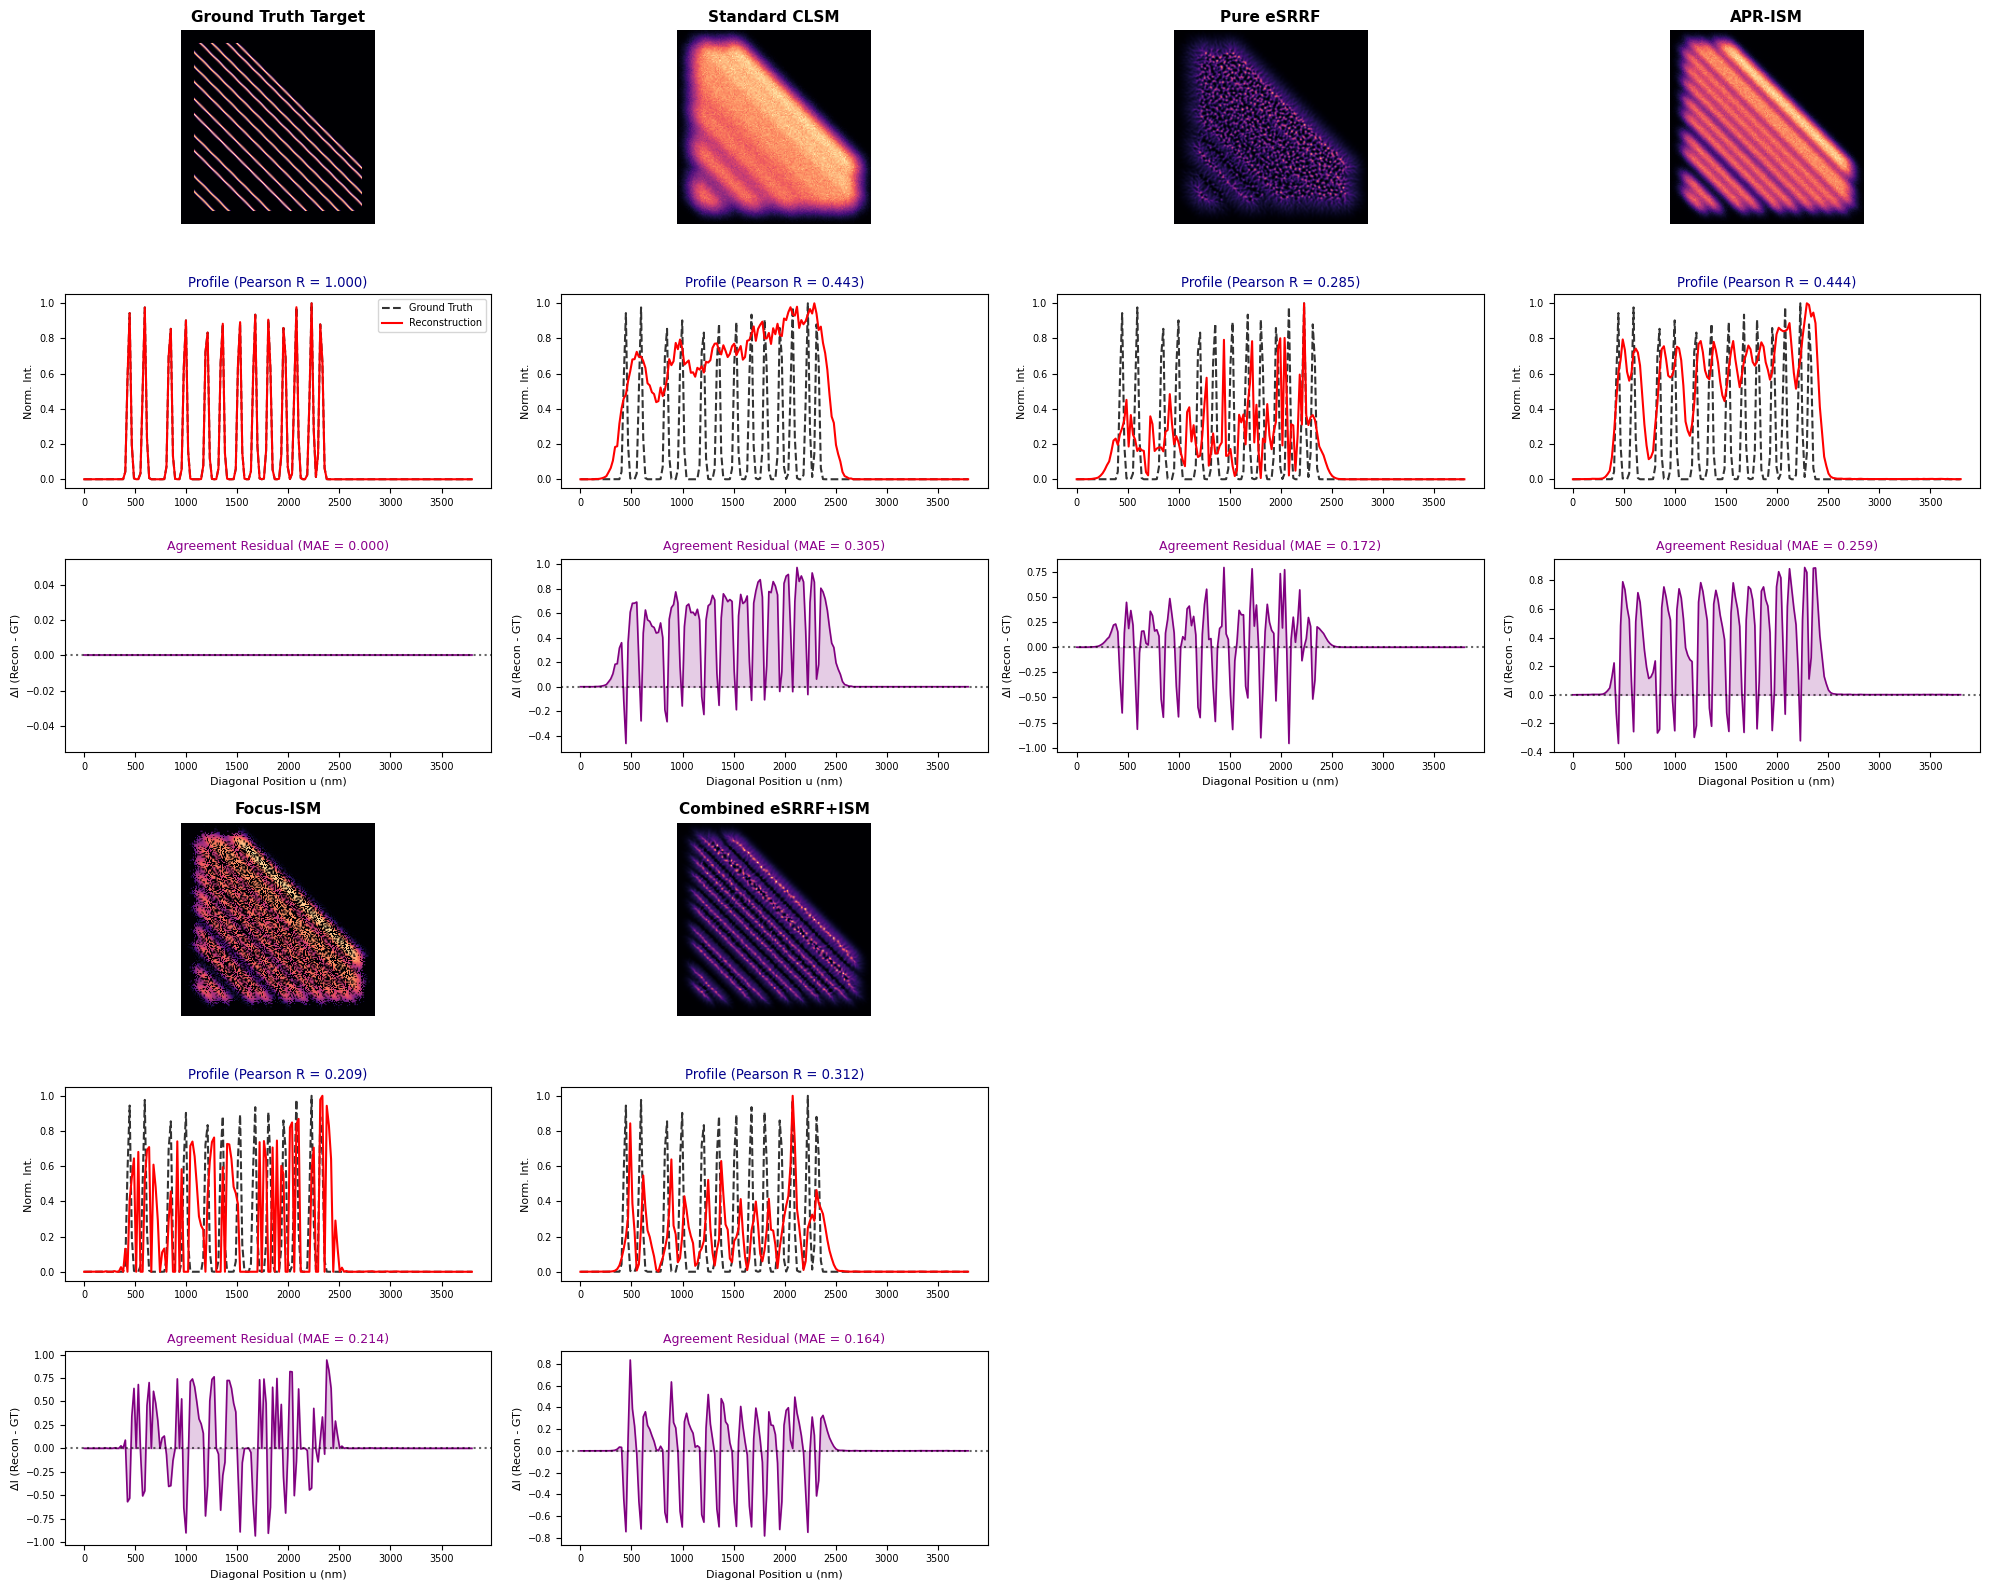

In [9]:
if __name__ == "__main__":
    run_line_pattern_demo()